In [1]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import numpy as np
from datasets import load_dataset
from collections import defaultdict, Counter
import random
import json

In [2]:
ALL_CATEGORY_FILES = [
    "All_Beauty.jsonl", "Amazon_Fashion.jsonl", "Appliances.jsonl",
    "Arts_Crafts_and_Sewing.jsonl", "Automotive.jsonl", "Baby_Products.jsonl",
    "Beauty_and_Personal_Care.jsonl", "Books.jsonl", "CDs_and_Vinyl.jsonl",
    "Cell_Phones_and_Accessories.jsonl", "Clothing_Shoes_and_Jewelry.jsonl",
    "Digital_Music.jsonl", "Electronics.jsonl", "Gift_Cards.jsonl",
    "Grocery_and_Gourmet_Food.jsonl", "Handmade_Products.jsonl",
    "Health_and_Household.jsonl", "Health_and_Personal_Care.jsonl",
    "Home_and_Kitchen.jsonl", "Industrial_and_Scientific.jsonl",
    "Kindle_Store.jsonl", "Magazine_Subscriptions.jsonl", "Movies_and_TV.jsonl",
    "Musical_Instruments.jsonl", "Office_Products.jsonl",
    "Patio_Lawn_and_Garden.jsonl", "Pet_Supplies.jsonl", "Software.jsonl",
    "Sports_and_Outdoors.jsonl", "Subscription_Boxes.jsonl",
    "Tools_and_Home_Improvement.jsonl", "Toys_and_Games.jsonl",
    "Unknown.jsonl", "Video_Games.jsonl"
]
len(ALL_CATEGORY_FILES)

34

In [3]:
CATEGORY_NAME = "Amazon_Fashion"
FILE_URL = "https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/resolve/main/raw/review_categories/{}.jsonl".format(CATEGORY_NAME)


dataset = load_dataset("json", data_files=FILE_URL)
stream = dataset['train']
print(dataset["train"][0].keys())

raw/review_categories/Amazon_Fashion.jso(…):   0%|          | 0.00/1.05G [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

dict_keys(['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase'])


In [4]:
df = dataset["train"].to_pandas()
grouped_df = df.groupby("parent_asin")

原始总评论数: 2500939
筛选 'verified_purchase' 后评论数: 2337702

--- 数据分析结果 ---
总独立商品数量 (处理后): 776976

--- 每个商品的评论数 (描述性统计) ---
count    776976.000000
mean          3.008718
std          18.697827
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max        7202.000000
Name: review_count, dtype: float64

--- Generating histogram... ---


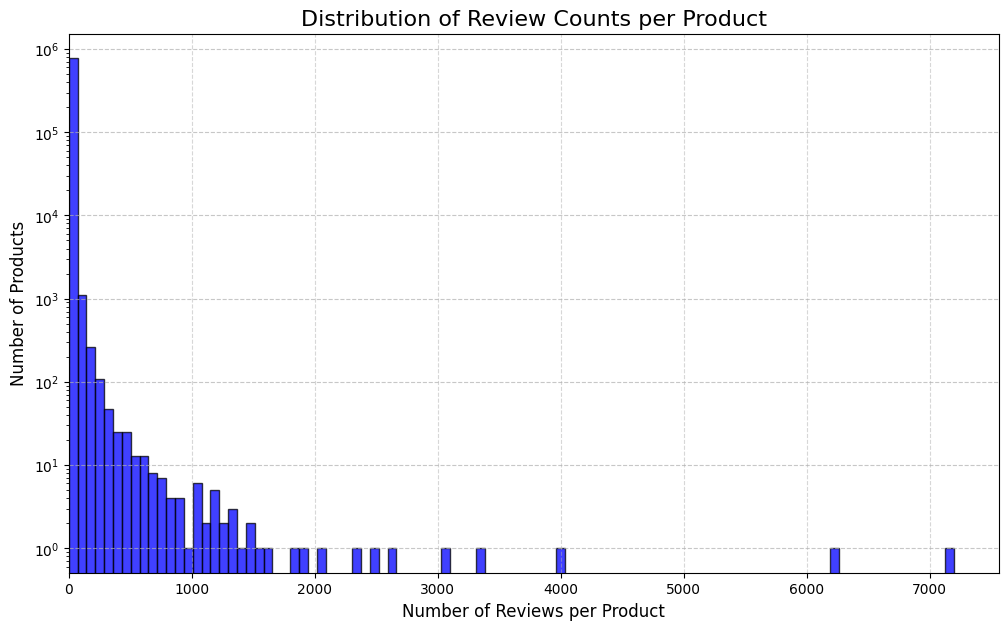

In [5]:
df_verified = df[df['verified_purchase'] == True]

# 3. 选择你需要的列
columns_to_keep = [
    'parent_asin',
    'rating',
    'title',
    'text',
    'images',
    'user_id',
    'timestamp',
    'helpful_vote'
]
df_processed = df_verified[columns_to_keep]

print(f"原始总评论数: {len(df)}")
print(f"筛选 'verified_purchase' 后评论数: {len(df_processed)}")

# 4. 按 'parent_asin' 分组，并计算每个商品的评论数
# .size() 会返回一个 Series，其索引是 parent_asin，值是该商品的行数（即评论数）
review_counts_per_product = df_processed.groupby('parent_asin').size().rename('review_count')

# 5. 分析结果
print("\n--- 数据分析结果 ---")
print(f"总独立商品数量 (处理后): {len(review_counts_per_product)}")

print("\n--- 每个商品的评论数 (描述性统计) ---")
print(review_counts_per_product.describe())

# 6. 可视化：绘制评论数量分布的直方图
# 我们将用 plt.hist() 替换 sns.histplot() 来修复这个渲染bug
print("\n--- Generating histogram... ---")

plt.figure(figsize=(12, 7))

# Use Matplotlib's hist function
# log=True automatically sets the Y-axis to a logarithmic scale
# bins=100 divides the data into 100 equal-width bins
plt.hist(review_counts_per_product, bins=100, log=True, facecolor='blue', alpha=0.75, edgecolor='black')

# Set labels and title in English
plt.title('Distribution of Review Counts per Product', fontsize=16)
plt.xlabel(f'Number of Reviews per Product', fontsize=12)
plt.ylabel('Number of Products', fontsize=12)

# Add grid lines for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Set the X-axis limits clearly, starting from 0
plt.xlim(left=0, right=review_counts_per_product.max() * 1.05)

plt.show()

In [6]:
MIN_REVIEWS_PER_PRODUCT = 20  # 您的标准：至少20条评论
NUM_PRODUCTS_TO_SAMPLE = 100 # 您的标准：随机抽样100个产品
OUTPUT_FILE = "step1_filtered_product_ids.txt" # 保存结果的文件

# --- 2. 开始任务 ---
print(f"--- Step 1 开始：筛选高价值产品 ---")
print(f"🎯 目标类别: {CATEGORY_NAME}")
print(f"🔗 数据源: {FILE_URL}")
print(f"📊 筛选标准: > {MIN_REVIEWS_PER_PRODUCT} 条评论的产品")
print(f" sampling 数量: {NUM_PRODUCTS_TO_SAMPLE} 个")

# --- 3. 加载与处理数据 ---
product_review_counts = defaultdict(int)

print("\n⏳ 正在流式读取数据并统计评论数...")
print("这可能需要一些时间，具体取决于类别大小...")

count = 0
for review in stream:
    if 'asin' in review:
        product_review_counts[review['asin']] += 1

    count += 1
    if count % 500000 == 0: # 每处理50万条评论打印一次进度
        print(f"  ...已处理 {count:,} 条评论。")

print(f"\n✅ 流式处理完成。共处理 {count:,} 条评论。")
print(f"  共发现 {len(product_review_counts):,} 个独立产品 (asin)。")

# --- 4. 筛选产品 ---
print(f"\n⏳ 正在筛选评论数 > {MIN_REVIEWS_PER_PRODUCT} 的产品...")

filtered_products = [
    asin for asin, num_reviews in product_review_counts.items()
    if num_reviews > MIN_REVIEWS_PER_PRODUCT
]

print(f"  筛选完毕！共 {len(filtered_products):,} 个产品符合条件。")

# --- 5. 抽样产品 ---
if len(filtered_products) == 0:
    print(f"❌ 错误：没有找到评论数超过 {MIN_REVIEWS_PER_PRODUCT} 的产品。")
    print("  请尝试降低 MIN_REVIEWS_PER_PRODUCT 的值。")
elif len(filtered_products) > NUM_PRODUCTS_TO_SAMPLE:
    sampled_product_ids = random.sample(filtered_products, NUM_PRODUCTS_TO_SAMPLE)
    print(f"  已成功随机抽取 {len(sampled_product_ids)} 个产品。")
else:
    # 如果符合条件的产品总数少于100，则全部使用
    sampled_product_ids = filtered_products
    print(f"  符合条件的产品不足 {NUM_PRODUCTS_TO_SAMPLE} 个，将使用全部 {len(sampled_product_ids)} 个产品。")

# --- 6. 保存结果 ---
if len(sampled_product_ids) > 0:
    with open(OUTPUT_FILE, 'w') as f:
        for asin in sampled_product_ids:
            f.write(asin + '\n')

    print(f"\n🎉 Step 1 完成！")
    print(f"已将 {len(sampled_product_ids)} 个产品ID保存到: {OUTPUT_FILE}")
    print("\n--- (抽样预览) ---")
    print(sampled_product_ids[:10]) # 打印前10个ID作为预览
    print("--------------------")

--- Step 1 开始：筛选高价值产品 ---
🎯 目标类别: Amazon_Fashion
🔗 数据源: https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/resolve/main/raw/review_categories/Amazon_Fashion.jsonl
📊 筛选标准: > 20 条评论的产品
 sampling 数量: 100 个

⏳ 正在流式读取数据并统计评论数...
这可能需要一些时间，具体取决于类别大小...
  ...已处理 500,000 条评论。
  ...已处理 1,000,000 条评论。
  ...已处理 1,500,000 条评论。
  ...已处理 2,000,000 条评论。
  ...已处理 2,500,000 条评论。

✅ 流式处理完成。共处理 2,500,939 条评论。
  共发现 874,297 个独立产品 (asin)。

⏳ 正在筛选评论数 > 20 的产品...
  筛选完毕！共 12,401 个产品符合条件。
  已成功随机抽取 100 个产品。

🎉 Step 1 完成！
已将 100 个产品ID保存到: step1_filtered_product_ids.txt

--- (抽样预览) ---
['B01N30EU9I', 'B01I2UHVTM', 'B00EJAC60O', 'B01CVJVTVG', 'B09NW1VKH6', 'B00RTCQ8ZS', 'B07VG1RY81', 'B00BGK3SJI', 'B08SC36ZPQ', 'B00GJXXIAQ']
--------------------


In [7]:
OUTPUT_FILE = "step1_pass1_user_counts.json"

# --- 2. 开始任务 ---
print(f"--- Step 1.1 (Pass 1) 开始：建立用户数据库 ---")
print(f"🎯 目标类别: {CATEGORY_NAME}")
print(f"🔗 数据源: {FILE_URL}")
print(f"📊 目标: 统计每个 user_id 的 'verified_purchase' 评论数")

# --- 3. 加载与处理数据 ---
user_review_counts = defaultdict(int)

count = 0
verified_count = 0
for review in stream:
    count += 1

    # 核心筛选逻辑：只统计 verified_purchase == True 的评论
    # 使用 .get() 来安全处理可能缺失的键
    if review.get('verified_purchase', False) == True:
        verified_count += 1
        if review.get('user_id'): # 确保 user_id 存在
            user_review_counts[review['user_id']] += 1

    if count % 500000 == 0:
        print(f"  ...已处理 {count:,} 条评论。")

print(f"\n✅ (Pass 1) 流式处理完成。")
print(f"  共处理 {count:,} 条评论。")
print(f"  其中 'verified_purchase' 为 True 的有 {verified_count:,} 条。")
print(f"  共找到 {len(user_review_counts):,} 个独立用户。")

# --- 4. 保存结果 ---
print(f"\n⏳ 正在将用户统计数据保存到 {OUTPUT_FILE}...")
with open(OUTPUT_FILE, 'w') as f:
    json.dump(user_review_counts, f)

print(f"\n🎉 Step 1.1 (Pass 1) 完成！")
print(f"  文件已保存: {OUTPUT_FILE}")

# 打印一些统计信息
rich_users = sum(1 for c in user_review_counts.values() if c >= 5)
print(f"  (统计信息) 评论数 >= 5 的“活跃用户”有 {rich_users:,} 人。")



--- Step 1.1 (Pass 1) 开始：建立用户数据库 ---
🎯 目标类别: Amazon_Fashion
🔗 数据源: https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/resolve/main/raw/review_categories/Amazon_Fashion.jsonl
📊 目标: 统计每个 user_id 的 'verified_purchase' 评论数
  ...已处理 500,000 条评论。
  ...已处理 1,000,000 条评论。
  ...已处理 1,500,000 条评论。
  ...已处理 2,000,000 条评论。
  ...已处理 2,500,000 条评论。

✅ (Pass 1) 流式处理完成。
  共处理 2,500,939 条评论。
  其中 'verified_purchase' 为 True 的有 2,337,702 条。
  共找到 1,937,340 个独立用户。

⏳ 正在将用户统计数据保存到 step1_pass1_user_counts.json...

🎉 Step 1.1 (Pass 1) 完成！
  文件已保存: step1_pass1_user_counts.json
  (统计信息) 评论数 >= 5 的“活跃用户”有 11,832 人。


In [8]:
USER_COUNTS_FILE = "step1_pass1_user_counts.json"

# --- 分析阈值 (您可以轻松调整) ---
# 1. 您的问题：分析评论数 > 20 的产品
MIN_TOTAL_REVIEWS_PER_PRODUCT = 20

# 2. 我们的定义：什么算“活跃用户”？
#    (您可以将 3 改为 2, 4, 5... 来重新运行分析)
MIN_REVIEWS_FOR_ACTIVE_USER = 3

# --- 2. 加载用户数据库 ---
print(f"--- Step 1.Analysis 开始：统计产品分布 ---")
print(f"LOAD: 正在加载用户数据库 '{USER_COUNTS_FILE}'...")

with open(USER_COUNTS_FILE, 'r') as f:
    user_counts = json.load(f)
print(f"  加载成功！共 {len(user_counts):,} 个用户的统计数据。")

# 转换为 set 以便快速查找“活跃用户”
rich_user_set = {
    user_id for user_id, count in user_counts.items()
    if count >= MIN_REVIEWS_FOR_ACTIVE_USER
}
print(f"  已定义 '活跃用户' (>= {MIN_REVIEWS_FOR_ACTIVE_USER} 条评论) 共: {len(rich_user_set):,} 人。")

# --- 3. 加载与处理数据 (Pass 2 / 分析) ---
# product_stats 结构: { 'asin_1': {'total_verified': 0, 'active_user_reviews': 0}, ... }
product_stats = defaultdict(lambda: {'total_verified': 0, 'active_user_reviews': 0})

try:
    print(f"\n⏳ 正在流式读取数据 (Pass 2 / 分析)...")
    print(f"  (目标) 统计 'total_verified' > {MIN_TOTAL_REVIEWS_PER_PRODUCT} 的产品")
    print(f"  (指标) 统计 'active_user_reviews' (来自 >= {MIN_REVIEWS_FOR_ACTIVE_USER} 条评论的用户)")

    count = 0
    for review in stream:
        count += 1

        # 仅限 'verified_purchase'
        if review.get('verified_purchase', False) == True:
            asin = review.get('asin')
            user_id = review.get('user_id')

            if not asin or not user_id:
                continue

            # 统计总数
            product_stats[asin]['total_verified'] += 1

            # 统计活跃用户评论数
            if user_id in rich_user_set:
                product_stats[asin]['active_user_reviews'] += 1

        if count % 500000 == 0:
            print(f"  ...已处理 {count:,} 条评论。")

    print(f"\n✅ (Pass 2) 流式处理完成。")
    print(f"  共处理 {count:,} 条评论，统计了 {len(product_stats):,} 个产品。")

    # --- 4. 执行统计分析 ---
    print(f"\n--- 📈 数据分析结果 (基于 '活跃用户' >= {MIN_REVIEWS_FOR_ACTIVE_USER} 条评论) ---")

    # 首先，筛选出总评论数 > 20 的产品
    # active_user_counts_list 列表将包含 [0, 2, 0, 5, 1, 1, 0, 3, ...]
    active_user_counts_list = []
    for asin, stats in product_stats.items():
        if stats['total_verified'] > MIN_TOTAL_REVIEWS_PER_PRODUCT:
            active_user_counts_list.append(stats['active_user_reviews'])

    # --- 回答问题 1 ---
    num_products_over_20 = len(active_user_counts_list)
    print(f"\n[问题 1: 总量统计]")
    print(f"  共有 {num_products_over_20:,} 个产品拥有 > {MIN_TOTAL_REVIEWS_PER_PRODUCT} 条 'verified' 评论。")

    if num_products_over_20 == 0:
        print("\n未找到符合条件的产品。请尝试降低 MIN_TOTAL_REVIEWS_PER_PRODUCT 的值。")
        sys.exit(0)

    # --- 回答问题 2 ---
    print(f"\n[问题 2: 活跃用户分布 (针对上述 {num_products_over_20:,} 个产品)]")

    dist_data = np.array(active_user_counts_list)

    print(f"  - 最大活跃评论数: {np.max(dist_data)}")
    print(f"  - 最小活跃评论数: {np.min(dist_data)}")
    print(f"  - 平均活跃评论数: {np.mean(dist_data):.2f}")
    print(f"  - 中位数 (50%):   {np.median(dist_data)}")
    print(f"  - 25% 百分位数:   {np.percentile(dist_data, 25)}")
    print(f"  - 75% 百分位数:   {np.percentile(dist_data, 75)}")
    print(f"  - 95% 百分位数:   {np.percentile(dist_data, 95)}")

    print("\n  [分布直方图 (频数统计)]")
    # 使用 Counter 来创建频数统计
    freq_dist = Counter(active_user_counts_list)

    print(f"  - 0 个活跃用户评论: {freq_dist.get(0, 0):,} 个产品")
    print(f"  - 1 个活跃用户评论: {freq_dist.get(1, 0):,} 个产品")
    print(f"  - 2 个活跃用户评论: {freq_dist.get(2, 0):,} 个产品")

    count_3_to_5 = sum(v for k, v in freq_dist.items() if 3 <= k <= 5)
    count_6_to_10 = sum(v for k, v in freq_dist.items() if 6 <= k <= 10)
    count_11_plus = sum(v for k, v in freq_dist.items() if k >= 11)

    print(f"  - 3-5 个活跃用户评论: {count_3_to_5:,} 个产品")
    print(f"  - 6-10 个活跃用户评论: {count_6_to_10:,} 个产品")
    print(f"  - 11+ 个活跃用户评论: {count_11_plus:,} 个产品")

except Exception as e:
    print(f"\n❌ 发生错误: {e}")

--- Step 1.Analysis 开始：统计产品分布 ---
LOAD: 正在加载用户数据库 'step1_pass1_user_counts.json'...
  加载成功！共 1,937,340 个用户的统计数据。
  已定义 '活跃用户' (>= 3 条评论) 共: 70,133 人。

⏳ 正在流式读取数据 (Pass 2 / 分析)...
  (目标) 统计 'total_verified' > 20 的产品
  (指标) 统计 'active_user_reviews' (来自 >= 3 条评论的用户)
  ...已处理 500,000 条评论。
  ...已处理 1,000,000 条评论。
  ...已处理 1,500,000 条评论。
  ...已处理 2,000,000 条评论。
  ...已处理 2,500,000 条评论。

✅ (Pass 2) 流式处理完成。
  共处理 2,500,939 条评论，统计了 822,603 个产品。

--- 📈 数据分析结果 (基于 '活跃用户' >= 3 条评论) ---

[问题 1: 总量统计]
  共有 11,621 个产品拥有 > 20 条 'verified' 评论。

[问题 2: 活跃用户分布 (针对上述 11,621 个产品)]
  - 最大活跃评论数: 198
  - 最小活跃评论数: 0
  - 平均活跃评论数: 4.78
  - 中位数 (50%):   3.0
  - 25% 百分位数:   1.0
  - 75% 百分位数:   6.0
  - 95% 百分位数:   14.0

  [分布直方图 (频数统计)]
  - 0 个活跃用户评论: 1,188 个产品
  - 1 个活跃用户评论: 1,750 个产品
  - 2 个活跃用户评论: 1,785 个产品
  - 3-5 个活跃用户评论: 3,731 个产品
  - 6-10 个活跃用户评论: 2,117 个产品
  - 11+ 个活跃用户评论: 1,050 个产品


In [9]:
import sys
from datasets import load_dataset
from collections import defaultdict
import json
import numpy as np

USER_COUNTS_FILE = "step1_pass1_user_counts.json"
TARGET_PRODUCTS_FILE = "step1_pass2_target_products.json"

# --- 分析阈值 ---
# 我们只关心这个问题： "总评论数 > 20"
MIN_TOTAL_REVIEWS_PER_PRODUCT = 20

# (此脚本不再需要 '活跃用户' 定义，因为我们只保存总数 > 20 的产品)

# --- 2. 加载用户数据库 ---
# (我们不需要加载 user_counts.json，因为此脚本只关心总数)
print(f"--- Step 1.Analysis-A (Pass 2) 开始：筛选并保存产品列表 ---")
print(f"🎯 目标类别: {CATEGORY_NAME}")
print(f"🔗 数据源: {FILE_URL}")

# --- 3. 加载与处理数据 (Pass 2) ---
# product_stats 结构: { 'asin_1': {'total_verified': 0}, ... }
product_stats = defaultdict(lambda: {'total_verified': 0})

try:
    print(f"  (目标) 统计 'total_verified' > {MIN_TOTAL_REVIEWS_PER_PRODUCT} 的产品")

    count = 0
    for review in stream:
        count += 1

        # 仅限 'verified_purchase'
        if review.get('verified_purchase', False) == True:
            asin = review.get('asin')
            if not asin:
                continue
            product_stats[asin]['total_verified'] += 1

        if count % 500000 == 0:
            print(f"  ...已处理 {count:,} 条评论。")

    print(f"\n✅ (Pass 2) 流式处理完成。")
    print(f"  共处理 {count:,} 条评论，统计了 {len(product_stats):,} 个产品。")

    # --- 4. 筛选并保存 ---
    print(f"\n⏳ 正在筛选 'total_verified' > {MIN_TOTAL_REVIEWS_PER_PRODUCT} 的产品...")

    target_product_asins = []
    for asin, stats in product_stats.items():
        if stats['total_verified'] > MIN_TOTAL_REVIEWS_PER_PRODUCT:
            target_product_asins.append(asin)

    num_target_products = len(target_product_asins)
    print(f"  筛选完毕！共 {num_target_products:,} 个产品符合条件。")

    if num_target_products > 0:
        print(f"  正在将这 {num_target_products:,} 个产品 ASIN 保存到 {TARGET_PRODUCTS_FILE}...")
        with open(TARGET_PRODUCTS_FILE, 'w') as f:
            json.dump(target_product_asins, f)
        print(f"  保存成功！")
    else:
        print("  未找到符合条件的产品。")

    print(f"\n🎉 Step 1.Analysis-A (Pass 2) 完成！")

except Exception as e:
    print(f"\n❌ 发生错误: {e}")

--- Step 1.Analysis-A (Pass 2) 开始：筛选并保存产品列表 ---
🎯 目标类别: Amazon_Fashion
🔗 数据源: https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/resolve/main/raw/review_categories/Amazon_Fashion.jsonl
  (目标) 统计 'total_verified' > 20 的产品
  ...已处理 500,000 条评论。
  ...已处理 1,000,000 条评论。
  ...已处理 1,500,000 条评论。
  ...已处理 2,000,000 条评论。
  ...已处理 2,500,000 条评论。

✅ (Pass 2) 流式处理完成。
  共处理 2,500,939 条评论，统计了 822,603 个产品。

⏳ 正在筛选 'total_verified' > 20 的产品...
  筛选完毕！共 11,621 个产品符合条件。
  正在将这 11,621 个产品 ASIN 保存到 step1_pass2_target_products.json...
  保存成功！

🎉 Step 1.Analysis-A (Pass 2) 完成！


In [10]:
import sys
from datasets import load_dataset
from collections import defaultdict, Counter
import json
import numpy as np

TARGET_PRODUCTS_FILE = "step1_pass2_target_products.json"

# --- 2. 加载目标产品列表 ---
print(f"--- Step 1.Analysis-B (Pass 3) 开始：分析 'helpful_vote' 分布 ---")
print(f"LOAD: 正在加载目标产品列表 '{TARGET_PRODUCTS_FILE}'...")
try:
    with open(TARGET_PRODUCTS_FILE, 'r') as f:
        target_product_list = json.load(f)

    # 转换为 Set 以实现 O(1) 快速查找
    target_product_set = set(target_product_list)

    print(f"  加载成功！共 {len(target_product_set):,} 个目标产品。")

except FileNotFoundError:
    print(f"❌ 错误：未找到文件 '{TARGET_PRODUCTS_FILE}'。")
    print("  请确保您已成功运行 'Step 1.Analysis-A (Pass 2)' 脚本。")
    sys.exit(1)
except Exception as e:
    print(f"❌ 加载 {TARGET_PRODUCTS_FILE} 时发生错误: {e}")
    sys.exit(1)

# --- 3. 加载与处理数据 (Pass 3) ---
# helpful_votes_list 将收集所有相关的 'helpful_vote' 值
helpful_votes_list = []

try:
    print(f"  (目标) 仅分析 {len(target_product_set):,} 个目标产品的 'helpful_vote'")

    count = 0
    relevant_reviews_count = 0
    for review in stream:
        count += 1

        # 筛选 1: 必须是 'verified_purchase'
        if review.get('verified_purchase', False) == True:
            asin = review.get('asin')

            # 筛选 2: 必须是我们的 5,119 个目标产品之一
            if asin in target_product_set:
                relevant_reviews_count += 1

                # 收集 'helpful_vote' 数据
                # .get('helpful_vote', 0) 确保如果字段缺失，默认为0
                helpful_votes_list.append(review.get('helpful_vote', 0))

        if count % 500000 == 0:
            print(f"  ...已处理 {count:,} 条评论。")

    print(f"\n✅ (Pass 3) 流式处理完成。")
    print(f"  共处理 {count:,} 条评论。")
    print(f"  共找到 {relevant_reviews_count:,} 条与目标产品相关的 'verified' 评论。")

    # --- 4. 执行 'helpful_vote' 统计分析 ---
    print(f"\n--- 📈 Helpful Vote 分析结果 (针对 {relevant_reviews_count:,} 条评论) ---")

    if relevant_reviews_count == 0:
        print("未找到任何相关评论。")
        sys.exit(0)

    dist_data = np.array(helpful_votes_list)

    print(f"  - 最大 'helpful_vote': {np.max(dist_data)}")
    print(f"  - 最小 'helpful_vote': {np.min(dist_data)}")
    print(f"  - 平均 'helpful_vote': {np.mean(dist_data):.2f}")
    print(f"  - 中位数 (50%):   {np.median(dist_data)}")
    print(f"  - 75% 百分位数:   {np.percentile(dist_data, 75)}")
    print(f"  - 90% 百分位数:   {np.percentile(dist_data, 90)}")
    print(f"  - 95% 百分位数:   {np.percentile(dist_data, 95)}")
    print(f"  - 99% 百分位数:   {np.percentile(dist_data, 99)}")

    print("\n  [分布直方图 (频数统计)]")
    # 使用 Counter 来创建频数统计
    freq_dist = Counter(helpful_votes_list)

    count_0 = freq_dist.get(0, 0)
    count_1 = freq_dist.get(1, 0)
    count_2 = freq_dist.get(2, 0)
    count_3_to_5 = sum(v for k, v in freq_dist.items() if 3 <= k <= 5)
    count_6_to_10 = sum(v for k, v in freq_dist.items() if 6 <= k <= 10)
    count_11_plus = sum(v for k, v in freq_dist.items() if k >= 11)

    print(f"  - 0 'helpful' (占比 {count_0 / relevant_reviews_count :.1%}): {count_0:,} 条评论")
    print(f"  - 1 'helpful' (占比 {count_1 / relevant_reviews_count :.1%}): {count_1:,} 条评论")
    print(f"  - 2 'helpful' (占比 {count_2 / relevant_reviews_count :.1%}): {count_2:,} 条评论")
    print(f"  - 3-5 'helpful'  : {count_3_to_5:,} 条评论")
    print(f"  - 6-10 'helpful' : {count_6_to_10:,} 条评论")
    print(f"  - 11+ 'helpful' : {count_11_plus:,} 条评论")

    print(f"\n🎉 Step 1.Analysis-B (Pass 3) 完成！")

except Exception as e:
    print(f"\n❌ 发生错误: {e}")

--- Step 1.Analysis-B (Pass 3) 开始：分析 'helpful_vote' 分布 ---
LOAD: 正在加载目标产品列表 'step1_pass2_target_products.json'...
  加载成功！共 11,621 个目标产品。
  (目标) 仅分析 11,621 个目标产品的 'helpful_vote'
  ...已处理 500,000 条评论。
  ...已处理 1,000,000 条评论。
  ...已处理 1,500,000 条评论。
  ...已处理 2,000,000 条评论。
  ...已处理 2,500,000 条评论。

✅ (Pass 3) 流式处理完成。
  共处理 2,500,939 条评论。
  共找到 551,748 条与目标产品相关的 'verified' 评论。

--- 📈 Helpful Vote 分析结果 (针对 551,748 条评论) ---
  - 最大 'helpful_vote': 708
  - 最小 'helpful_vote': 0
  - 平均 'helpful_vote': 0.70
  - 中位数 (50%):   0.0
  - 75% 百分位数:   0.0
  - 90% 百分位数:   1.0
  - 95% 百分位数:   3.0
  - 99% 百分位数:   12.0

  [分布直方图 (频数统计)]
  - 0 'helpful' (占比 80.9%): 446,109 条评论
  - 1 'helpful' (占比 10.7%): 59,297 条评论
  - 2 'helpful' (占比 3.1%): 17,350 条评论
  - 3-5 'helpful'  : 16,002 条评论
  - 6-10 'helpful' : 6,826 条评论
  - 11+ 'helpful' : 6,164 条评论

🎉 Step 1.Analysis-B (Pass 3) 完成！


In [11]:
import sys
from datasets import load_dataset
from collections import defaultdict
import json
import numpy as np

USER_COUNTS_FILE = "step1_pass1_user_counts.json"
GOLDEN_PRODUCTS_FILE = "step1_pass3_golden_product_asins.json"

# --- 筛选阈值 (根据您的分析) ---
# 1. '活跃用户' 定义
MIN_REVIEWS_FOR_ACTIVE_USER = 3
# 2. '产品池' 定义
MIN_TOTAL_REVIEWS_PER_PRODUCT = 20
# 3. '黄金集' 定义 (您的新标准: "拥有超过2个活跃用户评论"，即 >= 2)
MIN_ACTIVE_REVIEWS_PER_PRODUCT = 2

# --- 2. 加载用户数据库 ---
print(f"--- Step 1.C (Pass 2) 开始：筛选并保存 '黄金产品集' ---")
print(f"LOAD: 正在加载用户数据库 '{USER_COUNTS_FILE}'...")
try:
    with open(USER_COUNTS_FILE, 'r') as f:
        user_counts = json.load(f)

    rich_user_set = {
        user_id for user_id, count in user_counts.items()
        if count >= MIN_REVIEWS_FOR_ACTIVE_USER
    }
    print(f"  已定义 '活跃用户' (>= {MIN_REVIEWS_FOR_ACTIVE_USER} 条评论) 共: {len(rich_user_set):,} 人。")

except FileNotFoundError:
    print(f"❌ 错误：未找到文件 '{USER_COUNTS_FILE}'。")
    sys.exit(1)

# --- 3. 加载与处理数据 (Pass 2) ---
product_stats = defaultdict(lambda: {'total_verified': 0, 'active_user_reviews': 0})

try:
    print(f"  (标准1) 总评论数 > {MIN_TOTAL_REVIEWS_PER_PRODUCT}")
    print(f"  (标准2) 活跃用户评论数 >= {MIN_ACTIVE_REVIEWS_PER_PRODUCT}")

    count = 0
    for review in stream:
        count += 1
        if review.get('verified_purchase', False) == True:
            asin = review.get('asin')
            user_id = review.get('user_id')
            if not asin or not user_id:
                continue
            product_stats[asin]['total_verified'] += 1
            if user_id in rich_user_set:
                product_stats[asin]['active_user_reviews'] += 1

        if count % 500000 == 0:
            print(f"  ...已处理 {count:,} 条评论。")

    print(f"\n✅ (Pass 2) 流式处理完成。")
    print(f"  共处理 {count:,} 条评论，统计了 {len(product_stats):,} 个产品。")

    # --- 4. 筛选并保存 '黄金产品集' ---
    print(f"\n⏳ 正在根据双重标准筛选 '黄金产品集'...")

    golden_product_asins = []
    for asin, stats in product_stats.items():
        if (stats['total_verified'] > MIN_TOTAL_REVIEWS_PER_PRODUCT and
            stats['active_user_reviews'] >= MIN_ACTIVE_REVIEWS_PER_PRODUCT):
            golden_product_asins.append(asin)

    num_golden_products = len(golden_product_asins)
    print(f"  筛选完毕！共 {num_golden_products:,} 个 '黄金产品' 符合所有条件。")
    print(f"  (这应该与您计算的 1,791 个产品相符)")

    if num_golden_products > 0:
        print(f"  正在将这 {num_golden_products:,} 个产品 ASIN 保存到 {GOLDEN_PRODUCTS_FILE}...")
        with open(GOLDEN_PRODUCTS_FILE, 'w') as f:
            json.dump(golden_product_asins, f)
        print(f"  保存成功！")
    else:
        print("  未找到符合条件的产品。")

    print(f"\n🎉 Step 1.C (Pass 2) 完成！")

except Exception as e:
    print(f"\n❌ 发生错误: {e}")

--- Step 1.C (Pass 2) 开始：筛选并保存 '黄金产品集' ---
LOAD: 正在加载用户数据库 'step1_pass1_user_counts.json'...
  已定义 '活跃用户' (>= 3 条评论) 共: 70,133 人。
  (标准1) 总评论数 > 20
  (标准2) 活跃用户评论数 >= 2
  ...已处理 500,000 条评论。
  ...已处理 1,000,000 条评论。
  ...已处理 1,500,000 条评论。
  ...已处理 2,000,000 条评论。
  ...已处理 2,500,000 条评论。

✅ (Pass 2) 流式处理完成。
  共处理 2,500,939 条评论，统计了 822,603 个产品。

⏳ 正在根据双重标准筛选 '黄金产品集'...
  筛选完毕！共 8,683 个 '黄金产品' 符合所有条件。
  (这应该与您计算的 1,791 个产品相符)
  正在将这 8,683 个产品 ASIN 保存到 step1_pass3_golden_product_asins.json...
  保存成功！

🎉 Step 1.C (Pass 2) 完成！


In [12]:
import sys
from datasets import load_dataset
from collections import defaultdict, Counter
import json
import numpy as np


GOLDEN_PRODUCTS_FILE = "step1_pass3_golden_product_asins.json"

# --- 2. 加载 '黄金产品集' (1,791 个) ---
print(f"--- Step 1.D (Pass 3) 开始：分析 '黄金产品集' 的文本特性 ---")
print(f"LOAD: 正在加载黄金产品列表 '{GOLDEN_PRODUCTS_FILE}'...")
try:
    with open(GOLDEN_PRODUCTS_FILE, 'r') as f:
        golden_product_list = json.load(f)

    # 转换为 Set 以实现 O(1) 快速查找
    golden_product_set = set(golden_product_list)

    print(f"  加载成功！共 {len(golden_product_set):,} 个 '黄金产品'。")

except FileNotFoundError:
    print(f"❌ 错误：未找到文件 '{GOLDEN_PRODUCTS_FILE}'。")
    print("  请确保您已成功运行 'Step 1.C' 脚本。")
    sys.exit(1)
except Exception as e:
    print(f"❌ 加载 {GOLDEN_PRODUCTS_FILE} 时发生错误: {e}")
    sys.exit(1)

# --- 3. 加载与处理数据 (Pass 3) ---

# 用于 Q1: 收集所有相关评论的文本长度
all_text_lengths = []

# 用于 Q2: 统计每个产品在筛选后还剩多少评论
# 结构: {'asin_1': count, 'asin_2': count, ...}
post_filter_counts = defaultdict(int)

# 筛选条件
MIN_HELPFUL_VOTE = 1
MIN_TEXT_LENGTH = 30

try:
    print(f"  (目标) 仅分析 {len(golden_product_set):,} 个黄金产品的评论")

    count = 0
    relevant_reviews_count = 0
    for review in stream:
        count += 1

        # 筛选 1: 必须是 'verified_purchase'
        if review.get('verified_purchase', False) == True:
            asin = review.get('asin')

            # 筛选 2: 必须是我们的 1,791 个 '黄金产品' 之一
            if asin in golden_product_set:
                relevant_reviews_count += 1

                # --- Q1 数据收集 ---
                text = review.get('text', '')
                length = len(text)
                all_text_lengths.append(length)

                # --- Q2 数据收集 ---
                vote = review.get('helpful_vote', 0)

                # 应用您的双重筛选
                if vote >= MIN_HELPFUL_VOTE and length > MIN_TEXT_LENGTH:
                    post_filter_counts[asin] += 1

        if count % 500000 == 0:
            print(f"  ...已处理 {count:,} 条评论。")

    print(f"\n✅ (Pass 3) 流式处理完成。")
    print(f"  共处理 {count:,} 条评论。")
    print(f"  共找到 {relevant_reviews_count:,} 条与 '黄金产品' 相关的 'verified' 评论。")

    # --- 4. 统计分析 ---

    # --- Q1: 文本长度分布 ---
    print(f"\n--- 📈 Q1: 文本长度分布 (针对 {relevant_reviews_count:,} 条评论) ---")
    if relevant_reviews_count > 0:
        len_data = np.array(all_text_lengths)
        print(f"  - 最大长度: {np.max(len_data):,}")
        print(f"  - 最小长度: {np.min(len_data)}")
        print(f"  - 平均长度: {np.mean(len_data):.1f} 个字符")
        print(f"  - 中位数 (50%):   {np.median(len_data):.0f} 个字符")
        print(f"  - 25% 百分位数:   {np.percentile(len_data, 25):.0f} 个字符")
        print(f"  - 75% 百分位数:   {np.percentile(len_data, 75):.0f} 个字符")

        len_over_30 = sum(1 for l in all_text_lengths if l > 30)
        print(f"\n  - (参考) 长度 > 30 的评论占比: {len_over_30 / relevant_reviews_count :.1%} ({len_over_30:,} 条)")
    else:
        print("  未找到相关评论。")

    # --- Q2: 筛选后剩余评论数分布 ---
    print(f"\n--- 📈 Q2: 筛选后剩余评论数分布 (针对 {len(golden_product_set):,} 个产品) ---")
    print(f"    (筛选条件: helpful_vote >= {MIN_HELPFUL_VOTE} AND text_length > {MIN_TEXT_LENGTH})")

    # 获取每个产品剩余的评论数列表 [5, 0, 12, 3, 0, 8, ...]
    # 我们需要包括那些筛选后评论数为 0 的产品
    remaining_counts_per_product = []
    for asin in golden_product_set:
        remaining_counts_per_product.append(post_filter_counts.get(asin, 0))

    if len(remaining_counts_per_product) > 0:
        count_data = np.array(remaining_counts_per_product)
        print(f"  - (产品A) 剩余评论数 (最大): {np.max(count_data)}")
        print(f"  - (产品B) 剩余评论数 (最小): {np.min(count_data)}")
        print(f"  - (产品C) 剩余评论数 (平均): {np.mean(count_data):.1f} 条/产品")
        print(f"  - (产品D) 剩余评论数 (中位数): {np.median(count_data):.0f} 条/产品")
        print(f"  - (产品E) 剩余评论数 (75%): {np.percentile(count_data, 75):.0f} 条/产品")
        print(f"  - (产品F) 剩余评论数 (95%): {np.percentile(count_data, 95):.0f} 条/产品")

        num_products_with_zero = sum(1 for c in remaining_counts_per_product if c == 0)
        num_products_with_5plus = sum(1 for c in remaining_counts_per_product if c >= 5)
        num_products_with_10plus = sum(1 for c in remaining_counts_per_product if c >= 10)

        print(f"\n  [关键统计]")
        print(f"  - {num_products_with_zero:,} 个产品在筛选后剩余 0 条评论。")
        print(f"  - {num_products_with_5plus:,} 个产品在筛选后剩余 >= 5 条评论。")
        print(f"  - {num_products_with_10plus:,} 个产品在筛选后剩余 >= 10 条评论。")
    else:
        print("  未找到黄金产品。")

    print(f"\n🎉 Step 1.D (Pass 3) 分析完成！")

except Exception as e:
    print(f"\n❌ 发生错误: {e}")

--- Step 1.D (Pass 3) 开始：分析 '黄金产品集' 的文本特性 ---
LOAD: 正在加载黄金产品列表 'step1_pass3_golden_product_asins.json'...
  加载成功！共 8,683 个 '黄金产品'。
  (目标) 仅分析 8,683 个黄金产品的评论
  ...已处理 500,000 条评论。
  ...已处理 1,000,000 条评论。
  ...已处理 1,500,000 条评论。
  ...已处理 2,000,000 条评论。
  ...已处理 2,500,000 条评论。

✅ (Pass 3) 流式处理完成。
  共处理 2,500,939 条评论。
  共找到 460,041 条与 '黄金产品' 相关的 'verified' 评论。

--- 📈 Q1: 文本长度分布 (针对 460,041 条评论) ---
  - 最大长度: 7,740
  - 最小长度: 0
  - 平均长度: 131.6 个字符
  - 中位数 (50%):   82 个字符
  - 25% 百分位数:   36 个字符
  - 75% 百分位数:   167 个字符

  - (参考) 长度 > 30 的评论占比: 78.5% (361,211 条)

--- 📈 Q2: 筛选后剩余评论数分布 (针对 8,683 个产品) ---
    (筛选条件: helpful_vote >= 1 AND text_length > 30)
  - (产品A) 剩余评论数 (最大): 528
  - (产品B) 剩余评论数 (最小): 0
  - (产品C) 剩余评论数 (平均): 9.2 条/产品
  - (产品D) 剩余评论数 (中位数): 6 条/产品
  - (产品E) 剩余评论数 (75%): 11 条/产品
  - (产品F) 剩余评论数 (95%): 25 条/产品

  [关键统计]
  - 193 个产品在筛选后剩余 0 条评论。
  - 5,780 个产品在筛选后剩余 >= 5 条评论。
  - 2,702 个产品在筛选后剩余 >= 10 条评论。

🎉 Step 1.D (Pass 3) 分析完成！


In [13]:
import sys
from datasets import load_dataset
from collections import defaultdict
import json
import random

# --- 1. 配置参数 ---
USER_COUNTS_FILE = "step1_pass1_user_counts.json"
GOLDEN_PRODUCTS_FILE = "step1_pass3_golden_product_asins.json"
# 输出文件
FINAL_ANALYSIS_FILE = "step2_final_analysis_dataset.json"

# --- 2. 筛选阈值 ---
# (全局筛选)
MIN_HELPFUL_VOTE_GLOBAL = 1
MIN_TEXT_LENGTH_GLOBAL = 25
# (用户定义)
MIN_REVIEWS_FOR_ACTIVE_USER = 3
# (Input 阈值)
MIN_INPUT_REVIEWS = 15
MAX_INPUT_REVIEWS = 50
# (输出阈值)
TOTAL_DATA_PAIRS_TO_FIND = 400

# --- 3. 加载辅助文件 ---
print(f"--- Step 2 (最终结构化版) 开始：构建 400 组分析数据 ---")
print(f"  (全局筛选) vote >= {MIN_HELPFUL_VOTE_GLOBAL} AND 字符长度 >= {MIN_TEXT_LENGTH_GLOBAL}")
print(f"  (Input 筛选) 历史评论数 >= {MIN_INPUT_REVIEWS}")
try:
    with open(USER_COUNTS_FILE, 'r') as f:
        user_counts = json.load(f)
    active_user_set = {
        user_id for user_id, count in user_counts.items()
        if count >= MIN_REVIEWS_FOR_ACTIVE_USER
    }
    print(f"  加载成功！共 {len(active_user_set):,} 个 '活跃用户'。")

    with open(GOLDEN_PRODUCTS_FILE, 'r') as f:
        golden_product_list = json.load(f)
    golden_product_set = set(golden_product_list)
    print(f"  加载成功！共 {len(golden_product_set):,} 个 '黄金产品'。")

except FileNotFoundError as e:
    print(f"❌ 错误：未找到必要的文件: {e.filename}")
    sys.exit(1)

# --- 4. Pass 4: '两手抓' 数据收集 ---
print(f"\n⏳ 正在流式读取数据 (Pass 4) 并执行 '全局筛选'...")

# [新!] 内存存储 A: 按产品 (黄金产品)
product_reviews_in_memory = defaultdict(list)
# [新!] 内存存储 B: 按用户 (活跃用户)
user_reviews_in_memory = defaultdict(list)

try:
    count = 0
    collected_product_reviews = 0
    collected_user_reviews = 0

    for review in stream:
        count += 1

        # 筛选 1: 必须是 'verified'
        if review.get('verified_purchase', False) != True:
            continue

        asin = review.get('asin')
        user_id = review.get('user_id')

        # 筛选 2: 必须有 asin 和 user_id
        if not asin or not user_id:
            continue

        # 筛选 3: [新规则 1] 应用全局预处理筛选
        text = review.get('text', '')
        vote = review.get('helpful_vote', 0)

        if vote < MIN_HELPFUL_VOTE_GLOBAL or len(text) < MIN_TEXT_LENGTH_GLOBAL:
            continue

        # --- 评论通过所有全局筛选 ---

        review_data = {
            'asin': asin, # [新!] 必须保存 asin
            'rating': review.get('rating'),
            'title': review.get('title', ''),
            'text': text,
            'user_id': user_id,
            'timestamp': review.get('timestamp'),
            'helpful_vote': vote
        }

        # [新!] 存储 A: 按产品
        if asin in golden_product_set:
            product_reviews_in_memory[asin].append(review_data)
            collected_product_reviews += 1

        # [新!] 存储 B: 按用户
        if user_id in active_user_set:
            user_reviews_in_memory[user_id].append(review_data)
            collected_user_reviews += 1

        if count % 5000000 == 0:
            print(f"  ...已处理 {count:,} 条评论。")

    print(f"\n✅ (Pass 4) 流式处理完成。")
    print(f"  共收集了 {collected_product_reviews:,} 条 '黄金产品' 评论。")
    print(f"  共收集了 {collected_user_reviews:,} 条 '活跃用户' 评论。")

except Exception as e:
    print(f"❌ 发生错误: {e}")
    sys.exit(1)

# --- 5. 构建 400 组数据 ---
print(f"\n⏳ 正在构建 {TOTAL_DATA_PAIRS_TO_FIND} 组数据...")

all_possible_data_pairs = []

# 遍历 '黄金产品' 列表
for asin, reviews in product_reviews_in_memory.items():

    # 1. 按时间排序
    try:
        valid_reviews = [r for r in reviews if r.get('timestamp') is not None]
        valid_reviews.sort(key=lambda r: r['timestamp'])
    except Exception:
        print(f"  (警告) 产品 {asin} 存在时间戳错误，已跳过。")
        continue

    # 2. 遍历所有评论，寻找 '目标' (活跃用户的评论)
    for i, target_review in enumerate(valid_reviews):

        target_user_id = target_review['user_id']

        # 3. 检查是否为 '活跃用户'
        if target_user_id in active_user_set:

            target_timestamp = target_review['timestamp']

            # --- 4. 构建 Input ---
            input_list = valid_reviews[:i]

            # [新规则 2] 检查 Input 最小阈值
            if len(input_list) < MIN_INPUT_REVIEWS:
                continue

            if len(input_list) > MAX_INPUT_REVIEWS:
                input_list = random.sample(input_list, MAX_INPUT_REVIEWS)

            # --- 5. 构建 Output (结构化) ---
            output_dict = {
                "current_product_reviews": [],
                "other_product_reviews": []
            }

            # [新!] 从 'user_reviews_in_memory' 获取该用户的 *所有* 评论
            all_user_reviews = user_reviews_in_memory.get(target_user_id, [])

            for r in all_user_reviews:
                if r.get('timestamp') is None:
                    continue

                if r['asin'] == asin:
                    output_dict["current_product_reviews"].append(r)
                elif r['timestamp'] < target_timestamp: # 确保是 "过往"
                    output_dict["other_product_reviews"].append(r)

            # --- 6. 检查有效性 ---
            # Input 已保证 >= 15。我们必须确保 Output 至少有当前产品的评论。
            if len(output_dict["current_product_reviews"]) > 0:
                all_possible_data_pairs.append({
                    "input": input_list,
                    "output": output_dict
                })

# --- 6. 最终采样 ---
print(f"\n✅ 构建完成！共找到了 {len(all_possible_data_pairs):,} 组符合所有严格条件的数据对。")

if len(all_possible_data_pairs) == 0:
    print("❌ 错误：未找到任何有效的数据对。请尝试放宽筛选标准。")
    sys.exit(0)

# [新!] 去重：一个用户可能在一个产品上评论了多次，导致生成多个数据对
# 我们可以通过 "output" 中的 user_id 和 asin 来去重
unique_keys = set()
unique_data_pairs = []
for pair in all_possible_data_pairs:
    # 假设 'output.current_product_reviews' 至少有一条评论
    if pair['output']['current_product_reviews']:
        user_id = pair['output']['current_product_reviews'][0]['user_id']
        asin = pair['output']['current_product_reviews'][0]['asin']
        key = (user_id, asin)
        if key not in unique_keys:
            unique_keys.add(key)
            unique_data_pairs.append(pair)

print(f"  去重后，剩余 {len(unique_data_pairs):,} 组独立的数据对。")


if len(unique_data_pairs) > TOTAL_DATA_PAIRS_TO_FIND:
    print(f"  正在从 {len(unique_data_pairs):,} 组中随机抽取 {TOTAL_DATA_PAIRS_TO_FIND} 组...")
    final_dataset = random.sample(unique_data_pairs, TOTAL_DATA_PAIRS_TO_FIND)
else:
    print(f"  数据对总数 ({len(unique_data_pairs)}) 不足 {TOTAL_DATA_PAIRS_TO_FIND}，将使用所有数据。")
    final_dataset = unique_data_pairs

# --- 7. 保存最终文件 (JSON 格式) ---
print(f"\n⏳ 正在将 {len(final_dataset)} 组数据保存到 {FINAL_ANALYSIS_FILE}...")
try:
    with open(FINAL_ANALYSIS_FILE, 'w', encoding='utf-8') as f:
        json.dump(final_dataset, f, indent=2, ensure_ascii=False)

    print(f"\n🎉 任务完成！")
    print(f"  最终分析数据集已保存: {FINAL_ANALYSIS_FILE}")

    if final_dataset:
        print("\n--- (数据样本预览 - 1 组) ---")
        sample = final_dataset[0]
        print(f"  Input (上下文评论): {len(sample['input'])} 条 (>= {MIN_INPUT_REVIEWS})")
        print("  Output (结构化用户画像):")
        print(f"    - current_product_reviews: {len(sample['output']['current_product_reviews'])} 条")
        print(f"    - other_product_reviews: {len(sample['output']['other_product_reviews'])} 条")
        print("--------------------")

except Exception as e:
    print(f"❌ 保存文件时发生错误: {e}")

--- Step 2 (最终结构化版) 开始：构建 400 组分析数据 ---
  (全局筛选) vote >= 1 AND 字符长度 >= 25
  (Input 筛选) 历史评论数 >= 15
  加载成功！共 70,133 个 '活跃用户'。
  加载成功！共 8,683 个 '黄金产品'。

⏳ 正在流式读取数据 (Pass 4) 并执行 '全局筛选'...

✅ (Pass 4) 流式处理完成。
  共收集了 81,754 条 '黄金产品' 评论。
  共收集了 57,562 条 '活跃用户' 评论。

⏳ 正在构建 400 组数据...

✅ 构建完成！共找到了 1,573 组符合所有严格条件的数据对。
  去重后，剩余 1,496 组独立的数据对。
  正在从 1,496 组中随机抽取 400 组...

⏳ 正在将 400 组数据保存到 step2_final_analysis_dataset.json...

🎉 任务完成！
  最终分析数据集已保存: step2_final_analysis_dataset.json

--- (数据样本预览 - 1 组) ---
  Input (上下文评论): 21 条 (>= 15)
  Output (结构化用户画像):
    - current_product_reviews: 2 条
    - other_product_reviews: 0 条
--------------------


In [14]:
import sys
from datasets import load_dataset
from collections import defaultdict
import json
import random

# 输入文件
USER_COUNTS_FILE = "step1_pass1_user_counts.json"
GOLDEN_PRODUCTS_FILE = "step1_pass3_golden_product_asins.json"
# 输出文件
FINAL_ANALYSIS_FILE = "step2_final_analysis_dataset.json"

# --- 2. 筛选阈值 ---
# (全局筛选)
MIN_HELPFUL_VOTE_GLOBAL = 1
MIN_WORDS_GLOBAL = 25          # [已修正!] 评论的 词数 必须 >= 25
# (用户定义)
MIN_REVIEWS_FOR_ACTIVE_USER = 3
# (Input 阈值)
MIN_INPUT_REVIEWS = 15
MAX_INPUT_REVIEWS = 50
# (输出阈值)
TOTAL_DATA_PAIRS_TO_FIND = 400

# --- 3. 加载辅助文件 ---
print(f"--- Step 2 (最终词数修正版) 开始：构建 400 组分析数据 ---")
print(f"  (全局筛选) vote >= {MIN_HELPFUL_VOTE_GLOBAL} AND 词数 >= {MIN_WORDS_GLOBAL}")
print(f"  (Input 筛选) 历史评论数 >= {MIN_INPUT_REVIEWS}")
try:
    with open(USER_COUNTS_FILE, 'r') as f:
        user_counts = json.load(f)
    active_user_set = {
        user_id for user_id, count in user_counts.items()
        if count >= MIN_REVIEWS_FOR_ACTIVE_USER
    }
    print(f"  加载成功！共 {len(active_user_set):,} 个 '活跃用户'。")

    with open(GOLDEN_PRODUCTS_FILE, 'r') as f:
        golden_product_list = json.load(f)
    golden_product_set = set(golden_product_list)
    print(f"  加载成功！共 {len(golden_product_set):,} 个 '黄金产品'。")

except FileNotFoundError as e:
    print(f"❌ 错误：未找到必要的文件: {e.filename}")
    sys.exit(1)

# --- 4. Pass 4: '两手抓' 数据收集 ---
print(f"\n⏳ 正在流式读取数据 (Pass 4) 并执行 '全局筛选'...")

# 内存存储 A: 按产品 (黄金产品)
product_reviews_in_memory = defaultdict(list)
# 内存存储 B: 按用户 (活跃用户)
user_reviews_in_memory = defaultdict(list)

try:
    count = 0
    collected_product_reviews = 0
    collected_user_reviews = 0

    for review in stream:
        count += 1

        # 筛选 1: 'verified'
        if review.get('verified_purchase', False) != True:
            continue

        asin = review.get('asin')
        user_id = review.get('user_id')

        # 筛选 2: 必须有 asin 和 user_id
        if not asin or not user_id:
            continue

        # 筛选 3: [已修正] 应用全局预处理筛选
        text = review.get('text', '')
        vote = review.get('helpful_vote', 0)
        num_words = len(text.split()) # [已修正!] 按词数统计

        # [已修正!] 使用词数进行筛选
        if vote < MIN_HELPFUL_VOTE_GLOBAL or num_words < MIN_WORDS_GLOBAL:
            continue

        # --- 评论通过所有全局筛选 ---

        review_data = {
            'asin': asin,
            'rating': review.get('rating'),
            'title': review.get('title', ''),
            'text': text,
            'user_id': user_id,
            'timestamp': review.get('timestamp'),
            'helpful_vote': vote
            # (我们也可以在这里保存 'num_words' 以供调试)
            # 'num_words': num_words
        }

        # 存储 A: 按产品
        if asin in golden_product_set:
            product_reviews_in_memory[asin].append(review_data)
            collected_product_reviews += 1

        # 存储 B: 按用户
        if user_id in active_user_set:
            user_reviews_in_memory[user_id].append(review_data)
            collected_user_reviews += 1

        if count % 500000 == 0:
            print(f"  ...已处理 {count:,} 条评论。")

    print(f"\n✅ (Pass 4) 流式处理完成。")
    print(f"  共收集了 {collected_product_reviews:,} 条 '黄金产品' 评论 (通过词数筛选)。")
    print(f"  共收集了 {collected_user_reviews:,} 条 '活跃用户' 评论 (通过词数筛选)。")

except Exception as e:
    print(f"❌ 发生错误: {e}")
    sys.exit(1)

# --- 5. 构建 400 组数据 ---
print(f"\n⏳ 正在构建 {TOTAL_DATA_PAIRS_TO_FIND} 组数据...")

all_possible_data_pairs = []

# 遍历 '黄金产品' 列表
for asin, reviews in product_reviews_in_memory.items():

    # 1. 按时间排序
    try:
        valid_reviews = [r for r in reviews if r.get('timestamp') is not None]
        valid_reviews.sort(key=lambda r: r['timestamp'])
    except Exception:
        print(f"  (警告) 产品 {asin} 存在时间戳错误，已跳过。")
        continue

    # 2. 遍历所有评论，寻找 '目标' (活跃用户的评论)
    for i, target_review in enumerate(valid_reviews):

        target_user_id = target_review['user_id']

        # 3. 检查是否为 '活跃用户'
        if target_user_id in active_user_set:

            target_timestamp = target_review['timestamp']

            # --- 4. 构建 Input ---
            # (所有在 target 之前的、已预先过滤的评论)
            input_list = valid_reviews[:i]

            # [Input 阈值] 检查 Input 最小阈值
            if len(input_list) < MIN_INPUT_REVIEWS:
                continue

            if len(input_list) > MAX_INPUT_REVIEWS:
                input_list = random.sample(input_list, MAX_INPUT_REVIEWS)

            # --- 5. 构建 Output (结构化) ---
            output_dict = {
                "current_product_reviews": [],
                "other_product_reviews": []
            }

            # 从 'user_reviews_in_memory' 获取该用户的 *所有* 评论
            all_user_reviews = user_reviews_in_memory.get(target_user_id, [])

            for r in all_user_reviews:
                if r.get('timestamp') is None:
                    continue

                if r['asin'] == asin:
                    output_dict["current_product_reviews"].append(r)
                elif r['timestamp'] < target_timestamp: # 确保是 "过往"
                    output_dict["other_product_reviews"].append(r)

            # --- 6. 检查有效性 ---
            if len(output_dict["current_product_reviews"]) > 0:
                all_possible_data_pairs.append({
                    "input": input_list,
                    "output": output_dict
                })

# --- 6. 最终采样 ---
print(f"\n✅ 构建完成！共找到了 {len(all_possible_data_pairs):,} 组符合所有严格条件的数据对。")

if len(all_possible_data_pairs) == 0:
    print("❌ 错误：未找到任何有效的数据对。请尝试放宽筛选标准。")
    sys.exit(0)

# 去重
unique_keys = set()
unique_data_pairs = []
for pair in all_possible_data_pairs:
    if pair['output']['current_product_reviews']:
        user_id = pair['output']['current_product_reviews'][0]['user_id']
        asin = pair['output']['current_product_reviews'][0]['asin']
        key = (user_id, asin)
        if key not in unique_keys:
            unique_keys.add(key)
            unique_data_pairs.append(pair)

print(f"  去重后，剩余 {len(unique_data_pairs):,} 组独立的数据对。")


if len(unique_data_pairs) > TOTAL_DATA_PAIRS_TO_FIND:
    print(f"  正在从 {len(unique_data_pairs):,} 组中随机抽取 {TOTAL_DATA_PAIRS_TO_FIND} 组...")
    final_dataset = random.sample(unique_data_pairs, TOTAL_DATA_PAIRS_TO_FIND)
else:
    print(f"  数据对总数 ({len(unique_data_pairs)}) 不足 {TOTAL_DATA_PAIRS_TO_FIND}，将使用所有数据。")
    final_dataset = unique_data_pairs

# --- 7. 保存最终文件 (JSON 格式) ---
print(f"\n⏳ 正在将 {len(final_dataset)} 组数据保存到 {FINAL_ANALYSIS_FILE}...")
try:
    with open(FINAL_ANALYSIS_FILE, 'w', encoding='utf-8') as f:
        json.dump(final_dataset, f, indent=2, ensure_ascii=False)

    print(f"\n🎉 任务完成！")
    print(f"  最终分析数据集已保存: {FINAL_ANALYSIS_FILE}")

    if final_dataset:
        print("\n--- (数据样本预览 - 1 组) ---")
        sample = final_dataset[0]
        print(f"  Input (上下文评论): {len(sample['input'])} 条 (>= {MIN_INPUT_REVIEWS})")
        print("  Output (结构化用户画像):")
        print(f"    - current_product_reviews: {len(sample['output']['current_product_reviews'])} 条")
        print(f"    - other_product_reviews: {len(sample['output']['other_product_reviews'])} 条")
        print("--------------------")

except Exception as e:
    print(f"❌ 保存文件时发生错误: {e}")

--- Step 2 (最终词数修正版) 开始：构建 400 组分析数据 ---
  (全局筛选) vote >= 1 AND 词数 >= 25
  (Input 筛选) 历史评论数 >= 15
  加载成功！共 70,133 个 '活跃用户'。
  加载成功！共 8,683 个 '黄金产品'。

⏳ 正在流式读取数据 (Pass 4) 并执行 '全局筛选'...
  ...已处理 1,500,000 条评论。

✅ (Pass 4) 流式处理完成。
  共收集了 51,950 条 '黄金产品' 评论 (通过词数筛选)。
  共收集了 36,919 条 '活跃用户' 评论 (通过词数筛选)。

⏳ 正在构建 400 组数据...

✅ 构建完成！共找到了 423 组符合所有严格条件的数据对。
  去重后，剩余 396 组独立的数据对。
  数据对总数 (396) 不足 400，将使用所有数据。

⏳ 正在将 396 组数据保存到 step2_final_analysis_dataset.json...

🎉 任务完成！
  最终分析数据集已保存: step2_final_analysis_dataset.json

--- (数据样本预览 - 1 组) ---
  Input (上下文评论): 23 条 (>= 15)
  Output (结构化用户画像):
    - current_product_reviews: 1 条
    - other_product_reviews: 3 条
--------------------


In [15]:
#真正用的

USER_COUNTS_FILE = "step1_pass1_user_counts.json"
GOLDEN_PRODUCTS_FILE = "step1_pass3_golden_product_asins.json"
# 输出文件
FINAL_ANALYSIS_FILE = "step2_final_analysis_dataset.json"

# --- 2. 筛选阈值 ---
# --- (Input/Anchor 专用) ---
MIN_WORDS_FOR_INPUT = 5          # (新!) 词数 >= 5
MIN_INPUT_REVIEWS = 15
MAX_INPUT_REVIEWS = 50
# --- (Output/User 专用) ---
MIN_REVIEWS_FOR_ACTIVE_USER = 3
# --- (采样) ---
TOTAL_DATA_PAIRS_TO_FIND = 400

# --- 3. [新!] 分层采样函数 (规则 3) ---
def stratified_sample(reviews, target_count):
    """
    执行分层采样，确保好评和差评按比例被抽取
    """
    bin_low = [r for r in reviews if r['rating'] < 3.0]
    bin_high = [r for r in reviews if r['rating'] >= 3.0]

    random.shuffle(bin_low)
    random.shuffle(bin_high)

    total_low = len(bin_low)
    total_high = len(bin_high)
    total_all = total_low + total_high

    if total_all == 0:
        return []

    # 计算目标比例
    proportion_low = total_low / total_all
    target_low_samples = round(target_count * proportion_low)
    target_high_samples = target_count - target_low_samples

    # 抽取 (1): 按目标比例
    sampled_low = bin_low[:target_low_samples]
    sampled_high = bin_high[:target_high_samples]

    final_list = sampled_low + sampled_high

    # 抽取 (2): 补足剩余
    remaining_needed = target_count - len(final_list)
    if remaining_needed > 0:
        # 获取尚未被抽取的
        remaining_low_pool = bin_low[target_low_samples:]
        remaining_high_pool = bin_high[target_high_samples:]

        # 合并剩余池并打乱
        remaining_pool = remaining_low_pool + remaining_high_pool
        random.shuffle(remaining_pool)

        final_list.extend(remaining_pool[:remaining_needed])

    random.shuffle(final_list) # 再次打乱，确保最终顺序是随机的
    return final_list

# --- 4. 加载辅助文件 ---
print(f"--- Step 2 (最终分层采样版) 开始：构建 400 组分析数据 ---")
print(f"  (Input 标准 1) 词数 >= {MIN_WORDS_FOR_INPUT}")
print(f"  (Input 标准 2) 'rating < 3.0' (保留0-vote), 'rating >= 3.0' (必须 vote >= 1)")
print(f"  (Input 标准 3) 采样 > 50 时执行分层采样")

try:
    with open(USER_COUNTS_FILE, 'r') as f:
        user_counts = json.load(f)
    active_user_set = {
        user_id for user_id, count in user_counts.items()
        if count >= MIN_REVIEWS_FOR_ACTIVE_USER
    }
    print(f"  加载成功！共 {len(active_user_set):,} 个 '活跃用户'。")

    with open(GOLDEN_PRODUCTS_FILE, 'r') as f:
        golden_product_list = json.load(f)
    golden_product_set = set(golden_product_list)
    print(f"  加载成功！共 {len(golden_product_set):,} 个 '黄金产品'。")

except FileNotFoundError as e:
    print(f"❌ 错误：未找到必要的文件: {e.filename}")
    sys.exit(1)

# --- 5. Pass 4: '分离式' 数据收集 ---
print(f"\n⏳ 正在流式读取数据 (Pass 4) 并执行 '分离式筛选'...")

# 内存存储 A: 按产品 (用于 Input 和 Anchor) - [新! 条件筛选]
product_reviews_in_memory = defaultdict(list)
# 内存存储 B: 按用户 (用于 Output / Persona) - [宽松筛选]
user_reviews_in_memory = defaultdict(list)

try:
    count = 0
    collected_product_reviews = 0
    collected_user_reviews = 0

    for review in stream:
        count += 1

        # 筛选 1: 'verified'
        if review.get('verified_purchase', False) != True:
            continue

        asin = review.get('asin')
        user_id = review.get('user_id')

        # 筛选 2: 必须有 asin 和 user_id
        if not asin or not user_id:
            continue

        # --- [路径 B: 存储 Output/Persona 数据] ---
        # 仅应用宽松筛选 (user_id in active_set)
        # 我们在这里先处理，以确保所有 'verified' 评论都被捕获
        if user_id in active_user_set:
            user_reviews_in_memory[user_id].append({
                'asin': asin,
                'rating': review.get('rating'),
                'title': review.get('title', ''),
                'text': review.get('text', ''),
                'user_id': user_id,
                'timestamp': review.get('timestamp'),
                'helpful_vote': review.get('helpful_vote', 0)
            })
            collected_user_reviews += 1

        # --- [路径 A: 存储 Input/Anchor 数据] ---
        # 应用您精细的、多步骤的筛选

        # 0. 必须是 '黄金产品'
        if asin not in golden_product_set:
            continue

        # 1. 词数 >= 5 (规则 1)
        text = review.get('text', '')
        num_words = len(text.split())
        if num_words < MIN_WORDS_FOR_INPUT:
            continue

        # 2. 条件 Vote (规则 2)
        rating = review.get('rating')
        vote = review.get('helpful_vote', 0)

        if rating is None: # 丢弃没有评分的评论
            continue

        if rating >= 3.0:
            if vote < 1: # 好评/中评 必须有 vote
                continue
        # else (rating < 3.0):
            # 差评，我们保留它 (即使 vote == 0)

        # --- 评论通过所有 Input 筛选 ---
        product_reviews_in_memory[asin].append({
            'asin': asin,
            'rating': rating,
            'title': review.get('title', ''),
            'text': text,
            'user_id': user_id,
            'timestamp': review.get('timestamp'),
            'helpful_vote': vote
        })
        collected_product_reviews += 1

        if count % 500000 == 0:
            print(f"  ...已处理 {count:,} 条评论。")

    print(f"\n✅ (Pass 4) 流式处理完成。")
    print(f"  共收集了 {collected_product_reviews:,} 条 'Input/Anchor' 评论 (通过精细筛选)。")
    print(f"  共收集了 {collected_user_reviews:,} 条 'Output/Persona' 评论 (通过宽松筛选)。")

except Exception as e:
    print(f"❌ 发生错误: {e}")
    sys.exit(1)

# --- 6. 构建 400 组数据 ---
print(f"\n⏳ 正在构建 {TOTAL_DATA_PAIRS_TO_FIND} 组数据...")

all_possible_data_pairs = []

# 遍历 '黄金产品' 列表 (已通过严格筛选)
for asin, reviews in product_reviews_in_memory.items():

    # 1. 按时间排序
    try:
        valid_reviews = [r for r in reviews if r.get('timestamp') is not None]
        valid_reviews.sort(key=lambda r: r['timestamp'])
    except Exception:
        print(f"  (警告) 产品 {asin} 存在时间戳错误，已跳过。")
        continue

    # 2. 遍历所有 '高品质' 评论，寻找 '目标' (Anchor)
    for i, target_review in enumerate(valid_reviews):

        target_user_id = target_review['user_id']

        # 3. 检查 '高品质' 评论的作者是否为 '活跃用户'
        if target_user_id in active_user_set:

            target_timestamp = target_review['timestamp']

            # --- 4. 构建 Input ---
            input_list_full = valid_reviews[:i]

            # [Input 阈值] 检查 Input 最小阈值
            if len(input_list_full) < MIN_INPUT_REVIEWS:
                continue

            # [新! 规则 3] 检查是否需要分层采样
            if len(input_list_full) > MAX_INPUT_REVIEWS:
                input_list = stratified_sample(input_list_full, MAX_INPUT_REVIEWS)
            else:
                input_list = input_list_full # 全部使用

            # --- 5. 构建 Output (结构化) ---
            output_dict = {
                "current_product_reviews": [],
                "other_product_reviews": []
            }

            all_user_reviews = user_reviews_in_memory.get(target_user_id, [])

            for r in all_user_reviews:
                r_ts = r.get('timestamp')
                if r_ts is None:
                    continue

                if r['asin'] == asin:
                    output_dict["current_product_reviews"].append(r)
                elif r_ts < target_timestamp: # 确保是 "过往"
                    output_dict["other_product_reviews"].append(r)

            # --- 6. 检查有效性 ---
            if len(output_dict["current_product_reviews"]) > 0:
                all_possible_data_pairs.append({
                    "input": input_list,
                    "output": output_dict
                })

# --- 7. 最终采样 ---
print(f"\n✅ 构建完成！共找到了 {len(all_possible_data_pairs):,} 组符合所有严格条件的数据对。")

if len(all_possible_data_pairs) == 0:
    print("❌ 错误：未找到任何有效的数据对。请尝试放宽筛选标准。")
    sys.exit(0)

# 去重
unique_keys = set()
unique_data_pairs = []
for pair in all_possible_data_pairs:
    if pair['output']['current_product_reviews']:
        user_id = pair['output']['current_product_reviews'][0]['user_id']
        asin = pair['output']['current_product_reviews'][0]['asin']
        key = (user_id, asin)
        if key not in unique_keys:
            unique_keys.add(key)
            unique_data_pairs.append(pair)

print(f"  去重后，剩余 {len(unique_data_pairs):,} 组独立的数据对。")

if len(unique_data_pairs) > TOTAL_DATA_PAIRS_TO_FIND:
    print(f"  正在从 {len(unique_data_pairs):,} 组中随机抽取 {TOTAL_DATA_PAIRS_TO_FIND} 组...")
    final_dataset = random.sample(unique_data_pairs, TOTAL_DATA_PAIRS_TO_FIND)
else:
    print(f"  数据对总数 ({len(unique_data_pairs)}) 不足 {TOTAL_DATA_PAIRS_TO_FIND}，将使用所有数据。")
    final_dataset = unique_data_pairs

# --- 8. 保存最终文件 (JSON 格式) ---
print(f"\n⏳ 正在将 {len(final_dataset)} 组数据保存到 {FINAL_ANALYSIS_FILE}...")
try:
    with open(FINAL_ANALYSIS_FILE, 'w', encoding='utf-8') as f:
        json.dump(final_dataset, f, indent=2, ensure_ascii=False)

    print(f"\n🎉 任务完成！")
    print(f"  最终分析数据集已保存: {FINAL_ANALYSIS_FILE}")

    if final_dataset:
        print("\n--- (数据样本预览 - 1 组) ---")
        sample = final_dataset[0]
        print(f"  Input (上下文评论): {len(sample['input'])} 条 (>= {MIN_INPUT_REVIEWS})")
        print("  Output (结构化用户画像):")
        print(f"    - current_product_reviews: {len(sample['output']['current_product_reviews'])} 条 (完整画像)")
        print(f"    - other_product_reviews: {len(sample['output']['other_product_reviews'])} 条 (完整画像)")
        print("--------------------")

except Exception as e:
    print(f"❌ 保存文件时发生错误: {e}")

--- Step 2 (最终分层采样版) 开始：构建 400 组分析数据 ---
  (Input 标准 1) 词数 >= 5
  (Input 标准 2) 'rating < 3.0' (保留0-vote), 'rating >= 3.0' (必须 vote >= 1)
  (Input 标准 3) 采样 > 50 时执行分层采样
  加载成功！共 70,133 个 '活跃用户'。
  加载成功！共 8,683 个 '黄金产品'。

⏳ 正在流式读取数据 (Pass 4) 并执行 '分离式筛选'...

✅ (Pass 4) 流式处理完成。
  共收集了 133,151 条 'Input/Anchor' 评论 (通过精细筛选)。
  共收集了 267,656 条 'Output/Persona' 评论 (通过宽松筛选)。

⏳ 正在构建 400 组数据...

✅ 构建完成！共找到了 3,757 组符合所有严格条件的数据对。
  去重后，剩余 3,567 组独立的数据对。
  正在从 3,567 组中随机抽取 400 组...

⏳ 正在将 400 组数据保存到 step2_final_analysis_dataset.json...

🎉 任务完成！
  最终分析数据集已保存: step2_final_analysis_dataset.json

--- (数据样本预览 - 1 组) ---
  Input (上下文评论): 34 条 (>= 15)
  Output (结构化用户画像):
    - current_product_reviews: 1 条 (完整画像)
    - other_product_reviews: 4 条 (完整画像)
--------------------


In [16]:
#真正用的
import json
import numpy as np
from collections import Counter

# --- 1. 配置参数 ---
# 这是您在 Step 2 中生成的文件
FINAL_DATASET_FILE = "step2_final_analysis_dataset.json"

# --- 2. 加载数据 ---
print(f"--- Step 3: 分析最终数据集 ---")
print(f"LOAD: 正在加载 '{FINAL_DATASET_FILE}'...")
try:
    with open(FINAL_DATASET_FILE, 'r', encoding='utf-8') as f:
        final_dataset = json.load(f)
    print(f"  加载成功！共 {len(final_dataset)} 组数据。")
except FileNotFoundError:
    print(f"❌ 错误：未找到文件 '{FINAL_DATASET_FILE}'。")
    print("  请先运行 Step 2 脚本来生成此文件。")
    exit()
except Exception as e:
    print(f"❌ 加载文件时发生错误: {e}")
    exit()

# --- 3. 准备数据收集器 ---
# 1. 收集 review 数量
input_counts = []
output_current_counts = []
output_other_counts = []

# 2. 收集 rating 分布
input_ratings_global = []
output_ratings_global = [] # 合并 current 和 other

# --- 4. 遍历数据集 ---
print(f"⏳ 正在遍历 {len(final_dataset)} 组数据并进行统计...")
for i, pair in enumerate(final_dataset):
    try:
        # --- 1. 统计 Review 数量 ---
        input_list = pair.get('input', [])
        output_dict = pair.get('output', {})
        output_current = output_dict.get('current_product_reviews', [])
        output_other = output_dict.get('other_product_reviews', [])

        input_counts.append(len(input_list))
        output_current_counts.append(len(output_current))
        output_other_counts.append(len(output_other))

        # --- 2. 统计 Rating 分布 ---
        for review in input_list:
            if review.get('rating') is not None:
                input_ratings_global.append(review['rating'])

        for review in output_current:
            if review.get('rating') is not None:
                output_ratings_global.append(review['rating'])

        for review in output_other:
            if review.get('rating') is not None:
                output_ratings_global.append(review['rating'])

    except Exception as e:
        print(f"❌ 处理第 {i} 组数据时出错: {e}")

if not final_dataset:
    print("  数据集为空，无法分析。")
    exit()

# --- 5. 打印分析结果 ---

# --- 分析 1: Review 数量分布 ---
print(f"\n--- 📈 1. Review 数量分布 (基于 {len(final_dataset)} 组数据) ---")

def print_stats(name, counts):
    arr = np.array(counts)
    print(f"  {name}:")
    print(f"    - 平均 (Mean): {np.mean(arr):.1f} 条")
    print(f"    - 中位数 (Median): {np.median(arr):.0f} 条")
    print(f"    - 最小值 (Min): {np.min(arr)} 条")
    print(f"    - 最大值 (Max): {np.max(arr)} 条")
    if name.startswith('Output (other)'):
        zero_counts = sum(1 for c in counts if c == 0)
        print(f"    - '0条' (空列表) 的数量: {zero_counts} / {len(counts)} ({zero_counts/len(counts):.1%})")


print_stats("Input (上下文)", input_counts)
print_stats("Output (current)", output_current_counts)
print_stats("Output (other)", output_other_counts)

# --- 分析 2: Rating 分布 ---
print(f"\n--- 📈 2. Rating 分布 (全局) ---")

def print_rating_dist(name, ratings):
    total = len(ratings)
    if total == 0:
        print(f"  {name}: (未找到任何评分数据)")
        return

    counts = Counter(np.round(ratings)) # 四舍五入到整数
    print(f"  {name} (共 {total:,} 条评论):")
    for star in [1.0, 2.0, 3.0, 4.0, 5.0]:
        num = counts.get(star, 0)
        print(f"    - {star} 星: {num:7,} 条 ({num / total:6.1%})")
    print(f"    - 平均评分: {np.mean(ratings):.2f}")

print_rating_dist("INPUT 评论", input_ratings_global)
print_rating_dist("OUTPUT 评论", output_ratings_global)

print("\n🎉 分析完成！")

--- Step 3: 分析最终数据集 ---
LOAD: 正在加载 'step2_final_analysis_dataset.json'...
  加载成功！共 400 组数据。
⏳ 正在遍历 400 组数据并进行统计...

--- 📈 1. Review 数量分布 (基于 400 组数据) ---
  Input (上下文):
    - 平均 (Mean): 28.8 条
    - 中位数 (Median): 25 条
    - 最小值 (Min): 15 条
    - 最大值 (Max): 50 条
  Output (current):
    - 平均 (Mean): 1.1 条
    - 中位数 (Median): 1 条
    - 最小值 (Min): 1 条
    - 最大值 (Max): 5 条
  Output (other):
    - 平均 (Mean): 1.5 条
    - 中位数 (Median): 1 条
    - 最小值 (Min): 0 条
    - 最大值 (Max): 30 条
    - '0条' (空列表) 的数量: 127 / 400 (31.8%)

--- 📈 2. Rating 分布 (全局) ---
  INPUT 评论 (共 11,502 条评论):
    - 1.0 星:   3,703 条 ( 32.2%)
    - 2.0 星:   2,087 条 ( 18.1%)
    - 3.0 星:     805 条 (  7.0%)
    - 4.0 星:   1,164 条 ( 10.1%)
    - 5.0 星:   3,743 条 ( 32.5%)
    - 平均评分: 2.93
  OUTPUT 评论 (共 1,016 条评论):
    - 1.0 星:     226 条 ( 22.2%)
    - 2.0 星:     117 条 ( 11.5%)
    - 3.0 星:     103 条 ( 10.1%)
    - 4.0 星:     124 条 ( 12.2%)
    - 5.0 星:     446 条 ( 43.9%)
    - 平均评分: 3.44

🎉 分析完成！


In [17]:
#真正用的
import json

# --- 1. Configuration ---
INPUT_FILE = "step2_final_analysis_dataset.json"
OUTPUT_FILE = "step3_stringified_dataset_{}.json".format(CATEGORY_NAME)

# --- 2. Helper Function (Your Transformation Logic) ---

def stringify_review(review_dict):
    """
    Converts a single review dictionary into your specified string format.
    Example: "rating 5.0. Title text Body text"
    """
    try:
        # Get the individual components
        # .get(key, 'N/A') provides a default if 'rating' is missing
        rating = review_dict.get('rating', 'N/A')

        # .get(key, '') provides an empty string default
        # .strip() removes any leading/trailing whitespace
        title = review_dict.get('title', '').strip()
        text = review_dict.get('text', '').strip()

        # Build the string, handling cases where title might be empty
        parts = [f"rating {rating}."]
        if title:
            parts.append(title)
        if text:
            parts.append(text)

        # Join "rating 5.0." with the rest, e.g., "Title Body"
        return parts[0] + " " + " ".join(parts[1:])

    except Exception as e:
        print(f"Warning: Could not process review dict. Error: {e}")
        return "" # Return an empty string on failure

# --- 3. Main Script Logic ---

print(f"--- Step 3: Stringifying Dataset ---")
print(f"LOAD: Reading '{INPUT_FILE}'...")

try:
    with open(INPUT_FILE, 'r', encoding='utf-8') as f:
        original_dataset = json.load(f)
    print(f"  Loaded {len(original_dataset)} data pairs.")
except Exception as e:
    print(f"❌ Error: Could not read '{INPUT_FILE}'. {e}")
    exit()

new_stringified_dataset = []

print(f"⏳ Processing and stringifying all reviews...")

# Loop through each {"input": [...], "output": {...}} pair
for pair in original_dataset:

    # --- Process the 'input' list ---
    # Use a list comprehension to apply the function to every dict
    new_input_list = [
        stringify_review(review_dict)
        for review_dict in pair.get('input', [])
    ]

    # --- Process the 'output' dict ---
    original_output_dict = pair.get('output', {})

    new_current_reviews = [
        stringify_review(review_dict)
        for review_dict in original_output_dict.get('current_product_reviews', [])
    ]

    new_other_reviews = [
        stringify_review(review_dict)
        for review_dict in original_output_dict.get('other_product_reviews', [])
    ]

    # Rebuild the new pair with the stringified data
    new_pair = {
        "input": new_input_list,
        "output": {
            "current_product_reviews": new_current_reviews,
            "other_product_reviews": new_other_reviews
        }
    }

    new_stringified_dataset.append(new_pair)

# --- 4. Save the New File ---
print(f"\n⏳ Saving {len(new_stringified_dataset)} stringified pairs to '{OUTPUT_FILE}'...")
try:
    with open(OUTPUT_FILE, 'w', encoding='utf-8') as f:
        json.dump(new_stringified_dataset, f, indent=2, ensure_ascii=False)

    print(f"\n🎉 Task Complete!")
    print(f"  New file saved: {OUTPUT_FILE}")

    # Print a sample of the first item to verify
    if new_stringified_dataset:
        print("\n--- (Sample of first 'input' item) ---")
        print(new_stringified_dataset[0]['input'][0])
        print("---------------------------------")

except Exception as e:
    print(f"❌ Error: Could not save file. {e}")

--- Step 3: Stringifying Dataset ---
LOAD: Reading 'step2_final_analysis_dataset.json'...
  Loaded 400 data pairs.
⏳ Processing and stringifying all reviews...

⏳ Saving 400 stringified pairs to 'step3_stringified_dataset_Amazon_Fashion.json'...

🎉 Task Complete!
  New file saved: step3_stringified_dataset_Amazon_Fashion.json

--- (Sample of first 'input' item) ---
rating 3.0. Five Stars I can't close on of the clasps. I'll have to fix them before I can wear them.
---------------------------------


In [18]:
#删除中间生成的step1_filtered_product_ids.txt,step1_pass1_user_counts.json，step1_pass2_target_products.json，step1_pass3_golden_product_asins.json，step2_final_analysis_dataset.json
import os
files_to_delete = ["/Users/xinrui/Desktop/Stanford/cs329x/pj/SumForU-main/dataset/fetch_data/step1_filtered_product_ids.txt",
    "/Users/xinrui/Desktop/Stanford/cs329x/pj/SumForU-main/dataset/fetch_data/step1_pass1_user_counts.json",
    "/Users/xinrui/Desktop/Stanford/cs329x/pj/SumForU-main/dataset/fetch_data/step1_pass2_target_products.json",
    "/Users/xinrui/Desktop/Stanford/cs329x/pj/SumForU-main/dataset/fetch_data/step1_pass3_golden_product_asins.json",
    "/Users/xinrui/Desktop/Stanford/cs329x/pj/SumForU-main/dataset/fetch_data/step2_final_analysis_dataset.json"
]

for file_name in files_to_delete:
    if os.path.exists(file_name):
        os.remove(file_name)
        print(f"已删除文件: {file_name}")
    else:
        print(f"文件不存在，跳过: {file_name}")

已删除文件: /Users/xinrui/Desktop/Stanford/cs329x/pj/SumForU-main/dataset/fetch_data/step1_filtered_product_ids.txt
已删除文件: /Users/xinrui/Desktop/Stanford/cs329x/pj/SumForU-main/dataset/fetch_data/step1_pass1_user_counts.json
已删除文件: /Users/xinrui/Desktop/Stanford/cs329x/pj/SumForU-main/dataset/fetch_data/step1_pass2_target_products.json
已删除文件: /Users/xinrui/Desktop/Stanford/cs329x/pj/SumForU-main/dataset/fetch_data/step1_pass3_golden_product_asins.json
已删除文件: /Users/xinrui/Desktop/Stanford/cs329x/pj/SumForU-main/dataset/fetch_data/step2_final_analysis_dataset.json
